In [1]:
from google.colab import drive
drive.mount("/content/drive")

%cd /content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
!ls

Mounted at /content/drive
/content/drive/MyDrive/TUM/Pratikum/SliceGPTModifications
build		    experiments  pyproject.toml  src	     test.sh
build_and_test.sh   LICENSE	 README.md	 SUPPORT.md
CODE_OF_CONDUCT.md  pipelines	 SECURITY.md	 tests


In [ ]:
######################################################
#I'm gonna do something from skretch, easier for now##
######################################################

In [2]:
import os
import json
import math
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Base paths
# -----------------------------
BASE_RESULTS_DIR = "/content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments"
MODEL_DIR = os.path.join(BASE_RESULTS_DIR, "models_Qwen2-1.5B-Instruct_pca")
ANALYSIS_DIR = os.path.join(BASE_RESULTS_DIR, "analysis_Qwen2-1.5B-Instruct_pca_spike")

os.makedirs(ANALYSIS_DIR, exist_ok=True)

# -----------------------------
# Experiment config
# -----------------------------
DATASETS = ["coqa", "hotpotqa"]
SPARSITIES = [0.0, 0.10, 0.25, 0.40, 0.60]

# Use MLP outputs for the main analysis
ACTIVATION_KIND = "mlp_output"

# Representative layers
LAYERS_TO_ANALYZE = [4, 14, 26]

# PCA / spectrum config
TOP_K_EIGS_TO_SAVE = 200     # save first 200 eigenvalues for plotting, afterwards they should be too noisy
EPS = 1e-12

print("MODEL_DIR:", MODEL_DIR)
print("ANALYSIS_DIR:", ANALYSIS_DIR)
print("Datasets:", DATASETS)
print("Sparsities:", SPARSITIES)
print("Layers:", LAYERS_TO_ANALYZE)
print("Activation kind:", ACTIVATION_KIND)

MODEL_DIR: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca
ANALYSIS_DIR: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike
Datasets: ['coqa', 'hotpotqa']
Sparsities: [0.0, 0.1, 0.25, 0.4, 0.6]
Layers: [4, 14, 26]
Activation kind: mlp_output


In [3]:
def sparsity_to_tag(s: float) -> str:
    """
    0.0  -> s0p00
    0.1  -> s0p10
    0.25 -> s0p25
    """
    s_str = f"{s:.2f}"   # e.g. 0.10, 0.25
    return "s" + s_str.replace(".", "p")


def model_subdir(cal_ds: str, sparsity: float) -> str:
    return f"Qwen-Qwen2-1p5B-Instruct_{cal_ds}_{sparsity_to_tag(sparsity)}"


def hidden_state_file(cal_ds: str, sparsity: float, layer_idx: int, act_kind: str = ACTIVATION_KIND) -> str:
    subdir = model_subdir(cal_ds, sparsity)
    return os.path.join(MODEL_DIR, subdir, "hidden_states", f"layer_{layer_idx}_{act_kind}.pt")


# Quick sanity check
for ds in DATASETS:
    for s in SPARSITIES:
        print(model_subdir(ds, s))

Qwen-Qwen2-1p5B-Instruct_coqa_s0p00
Qwen-Qwen2-1p5B-Instruct_coqa_s0p10
Qwen-Qwen2-1p5B-Instruct_coqa_s0p25
Qwen-Qwen2-1p5B-Instruct_coqa_s0p40
Qwen-Qwen2-1p5B-Instruct_coqa_s0p60
Qwen-Qwen2-1p5B-Instruct_hotpotqa_s0p00
Qwen-Qwen2-1p5B-Instruct_hotpotqa_s0p10
Qwen-Qwen2-1p5B-Instruct_hotpotqa_s0p25
Qwen-Qwen2-1p5B-Instruct_hotpotqa_s0p40
Qwen-Qwen2-1p5B-Instruct_hotpotqa_s0p60


In [ ]:
# Example file to inspect, Run this first to confirm the tensor shape before doing the full experiment.
example_path = hidden_state_file("coqa", 0.25, 26)

print("Example path:", example_path)
print("Exists:", os.path.exists(example_path))

x = torch.load(example_path, map_location="cpu")

print("Type:", type(x))
if isinstance(x, torch.Tensor):
    print("Shape:", tuple(x.shape))
    print("Dtype:", x.dtype)
else:
    print("Loaded object is not a tensor. Type:", type(x))

Example path: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca/Qwen-Qwen2-1p5B-Instruct_coqa_s0p25/hidden_states/layer_26_mlp_output.pt
Exists: True
Type: <class 'list'>
Loaded object is not a tensor. Type: <class 'list'>


In [ ]:
#Inspect list contents first. Run this before the full pipeline.
example_path = hidden_state_file("coqa", 0.25, 26)

x = torch.load(example_path, map_location="cpu")

print("Top-level type:", type(x))
print("Length:", len(x))

print("\nFirst 5 element types:")
for i, item in enumerate(x[:5]):
    print(f"[{i}] type={type(item)}")
    if isinstance(item, torch.Tensor):
        print(f"    shape={tuple(item.shape)}, dtype={item.dtype}")

Top-level type: <class 'list'>
Length: 16

First 5 element types:
[0] type=<class 'torch.Tensor'>
    shape=(8, 2045, 1536), dtype=torch.float16
[1] type=<class 'torch.Tensor'>
    shape=(8, 2045, 1536), dtype=torch.float16
[2] type=<class 'torch.Tensor'>
    shape=(8, 2044, 1536), dtype=torch.float16
[3] type=<class 'torch.Tensor'>
    shape=(8, 2044, 1536), dtype=torch.float16
[4] type=<class 'torch.Tensor'>
    shape=(8, 2044, 1536), dtype=torch.float16


In [5]:
def pool_tensor_to_sample_features(t: torch.Tensor) -> torch.Tensor:
    """
    Convert one tensor to shape (N, d).

    Supported:
    - (N, d): already pooled
    - (N, T, d): mean-pool over tokens
    """
    if not isinstance(t, torch.Tensor):
        raise TypeError(f"Expected tensor, got {type(t)}")

    t = t.float().cpu()

    if t.ndim == 2:
        return t

    if t.ndim == 3:
        # mean pool over token dimension
        return t.mean(dim=1)

    raise ValueError(f"Unsupported tensor shape: {tuple(t.shape)}")


def to_sample_feature_matrix(x):
    """
    Converts a loaded hidden-state object into H in R^{N x d}.

    Supported input:
    - Tensor (N, d)
    - Tensor (N, T, d)
    - list of tensors, where T may vary across list elements

    Output:
    - H of shape (N, d)
    """
    if isinstance(x, torch.Tensor):
        return pool_tensor_to_sample_features(x)

    if isinstance(x, list):
        if len(x) == 0:
            raise ValueError("Loaded list is empty.")

        pooled_parts = []
        for i, item in enumerate(x):
            if not isinstance(item, torch.Tensor):
                raise TypeError(f"Element {i} is not a tensor: {type(item)}")
            pooled_parts.append(pool_tensor_to_sample_features(item))

        # now all tensors should be (batch_i, d), so concat is safe
        H = torch.cat(pooled_parts, dim=0)
        return H

    raise TypeError(f"Unsupported loaded object type: {type(x)}")

In [ ]:
example_path = hidden_state_file("coqa", 0.25, 26)
x = torch.load(example_path, map_location="cpu")

print("Top-level type:", type(x))
print("Length:", len(x))

for i, item in enumerate(x[:10]):
    if isinstance(item, torch.Tensor):
        print(f"[{i}] shape={tuple(item.shape)}, dtype={item.dtype}")
    else:
        print(f"[{i}] type={type(item)}")

Top-level type: <class 'list'>
Length: 16
[0] shape=(8, 2045, 1536), dtype=torch.float16
[1] shape=(8, 2045, 1536), dtype=torch.float16
[2] shape=(8, 2044, 1536), dtype=torch.float16
[3] shape=(8, 2044, 1536), dtype=torch.float16
[4] shape=(8, 2044, 1536), dtype=torch.float16
[5] shape=(8, 2045, 1536), dtype=torch.float16
[6] shape=(8, 2045, 1536), dtype=torch.float16
[7] shape=(8, 2044, 1536), dtype=torch.float16
[8] shape=(8, 2045, 1536), dtype=torch.float16
[9] shape=(8, 2044, 1536), dtype=torch.float16


In [6]:
example_path = hidden_state_file("coqa", 0.25, 26)
x = torch.load(example_path, map_location="cpu")

H = to_sample_feature_matrix(x)
print("Final H shape:", tuple(H.shape))
print("Final H dtype:", H.dtype)

Final H shape: (128, 1536)
Final H dtype: torch.float32


In [7]:
def pool_tensor_to_sample_features(t: torch.Tensor) -> torch.Tensor:
    """
    Convert one tensor to shape (N, d).

    Supported:
    - (N, d): already pooled
    - (N, T, d): mean-pool over tokens
    """
    if not isinstance(t, torch.Tensor):
        raise TypeError(f"Expected tensor, got {type(t)}")

    t = t.float().cpu()

    if t.ndim == 2:
        return t

    if t.ndim == 3:
        return t.mean(dim=1)

    raise ValueError(f"Unsupported tensor shape: {tuple(t.shape)}")


def to_sample_feature_matrix(x):
    """
    Converts a loaded hidden-state object into H in R^{N x d}.

    Supported input:
    - Tensor (N, d)
    - Tensor (N, T, d)
    - list of tensors, where T may vary across list elements
    """
    if isinstance(x, torch.Tensor):
        return pool_tensor_to_sample_features(x)

    if isinstance(x, list):
        if len(x) == 0:
            raise ValueError("Loaded list is empty.")

        pooled_parts = []
        for i, item in enumerate(x):
            if not isinstance(item, torch.Tensor):
                raise TypeError(f"Element {i} is not a tensor: {type(item)}")
            pooled_parts.append(pool_tensor_to_sample_features(item))

        return torch.cat(pooled_parts, dim=0)

    raise TypeError(f"Unsupported loaded object type: {type(x)}")

In [8]:
'''
This is the core analysis cell.
Still sanity check cell, and before that was just to set the experiment
Instead of explicitly building the covariance matrix first, we compute it from centered hidden states. Since hidden dimension is not too huge, this is fine.
'''
def compute_spectrum_and_effective_rank(H: torch.Tensor, top_k_to_save: int = TOP_K_EIGS_TO_SAVE):
    """
    Input:
        H: tensor of shape (N, d)
    Returns:
        dict with:
            - n_samples
            - hidden_dim
            - eigenvalues_topk
            - effective_rank
            - trace
            - stable_rank
    """
    H = H.float()

    # Center the samples
    Hc = H - H.mean(dim=0, keepdim=True)

    N, d = Hc.shape
    if N < 2:
        raise ValueError("Need at least 2 samples to compute covariance.")

    # Covariance: d x d
    C = (Hc.T @ Hc) / (N - 1)

    # Symmetric eigendecomposition
    eigvals = torch.linalg.eigvalsh(C)
    eigvals = torch.flip(eigvals, dims=[0])  # descending
    eigvals = torch.clamp(eigvals, min=0.0)

    eigvals_np = eigvals.cpu().numpy()

    # Normalize eigenvalues for entropy / effective rank
    trace = float(eigvals.sum().item())
    probs = eigvals / (eigvals.sum() + EPS)

    entropy = float((-(probs * torch.log(probs + EPS)).sum()).item())
    effective_rank = float(math.exp(entropy))

    # Stable rank: ||C||_F^2 / ||C||_2^2
    fro_sq = float((eigvals ** 2).sum().item())
    spec_sq = float((eigvals.max() ** 2).item()) if eigvals.numel() > 0 else 0.0
    stable_rank = float(fro_sq / (spec_sq + EPS))

    return {
        "n_samples": int(N),
        "hidden_dim": int(d),
        "eigenvalues_topk": eigvals_np[:top_k_to_save].tolist(),
        "effective_rank": effective_rank,
        "trace": trace,
        "stable_rank": stable_rank,
    }


# Test run
test_stats = compute_spectrum_and_effective_rank(H)
print("n_samples:", test_stats["n_samples"])
print("hidden_dim:", test_stats["hidden_dim"])
print("effective_rank:", test_stats["effective_rank"])
print("stable_rank:", test_stats["stable_rank"])
print("first 10 eigvals:", test_stats["eigenvalues_topk"][:10])

n_samples: 128
hidden_dim: 1536
effective_rank: 40.489942882445064
stable_rank: 1.6456051985445181
first 10 eigvals: [127.9545669555664, 74.2529296875, 38.031532287597656, 28.82561492919922, 18.873104095458984, 16.71068572998047, 15.833749771118164, 14.043023109436035, 13.302671432495117, 12.142058372497559]


In [ ]:
#Before looping over everything, run one manual case to verify output.
cal_ds = "coqa"
sparsity = 0.25
layer_idx = 26

path = hidden_state_file(cal_ds, sparsity, layer_idx)
print("Loading:", path)

x = torch.load(path, map_location="cpu")
H = to_sample_feature_matrix(x)
stats = compute_spectrum_and_effective_rank(H)

manual_result = {
    "calibration_dataset": cal_ds,
    "sparsity": sparsity,
    "layer": layer_idx,
    "activation_kind": ACTIVATION_KIND,
    **stats
}

manual_result

In [8]:
all_results = []

for cal_ds in DATASETS:
    for sparsity in SPARSITIES:
        for layer_idx in LAYERS_TO_ANALYZE:
            path = hidden_state_file(cal_ds, sparsity, layer_idx)

            if not os.path.exists(path):
                print(f"[WARNING] Missing file: {path}")
                continue

            print(f"[RUN] ds={cal_ds} | sparsity={sparsity} | layer={layer_idx}")

            x = torch.load(path, map_location="cpu")
            H = to_sample_feature_matrix(x)
            stats = compute_spectrum_and_effective_rank(H)

            result = {
                "calibration_dataset": cal_ds,
                "sparsity": sparsity,
                "layer": layer_idx,
                "activation_kind": ACTIVATION_KIND,
                **stats
            }

            # Save individual result
            out_name = f"{cal_ds}_s{sparsity:.2f}_layer{layer_idx}_{ACTIVATION_KIND}_spectrum.json"
            out_path = os.path.join(ANALYSIS_DIR, out_name)
            with open(out_path, "w") as f:
                json.dump(result, f, indent=2)

            all_results.append(result)

print(f"\nCompleted {len(all_results)} runs.")

[RUN] ds=coqa | sparsity=0.0 | layer=4
[RUN] ds=coqa | sparsity=0.0 | layer=14
[RUN] ds=coqa | sparsity=0.0 | layer=26
[RUN] ds=coqa | sparsity=0.1 | layer=4
[RUN] ds=coqa | sparsity=0.1 | layer=14
[RUN] ds=coqa | sparsity=0.1 | layer=26
[RUN] ds=coqa | sparsity=0.25 | layer=4
[RUN] ds=coqa | sparsity=0.25 | layer=14
[RUN] ds=coqa | sparsity=0.25 | layer=26
[RUN] ds=coqa | sparsity=0.4 | layer=4
[RUN] ds=coqa | sparsity=0.4 | layer=14
[RUN] ds=coqa | sparsity=0.4 | layer=26
[RUN] ds=coqa | sparsity=0.6 | layer=4
[RUN] ds=coqa | sparsity=0.6 | layer=14
[RUN] ds=coqa | sparsity=0.6 | layer=26
[RUN] ds=hotpotqa | sparsity=0.0 | layer=4
[RUN] ds=hotpotqa | sparsity=0.0 | layer=14
[RUN] ds=hotpotqa | sparsity=0.0 | layer=26
[RUN] ds=hotpotqa | sparsity=0.1 | layer=4
[RUN] ds=hotpotqa | sparsity=0.1 | layer=14
[RUN] ds=hotpotqa | sparsity=0.1 | layer=26
[RUN] ds=hotpotqa | sparsity=0.25 | layer=4
[RUN] ds=hotpotqa | sparsity=0.25 | layer=14
[RUN] ds=hotpotqa | sparsity=0.25 | layer=26
[RUN] 

In [9]:
#Plot effective rank vs sparsity
df = pd.DataFrame(all_results)

csv_path = os.path.join(ANALYSIS_DIR, f"summary_{ACTIVATION_KIND}.csv")
json_path = os.path.join(ANALYSIS_DIR, f"summary_{ACTIVATION_KIND}.json")

df.to_csv(csv_path, index=False)
with open(json_path, "w") as f:
    json.dump(all_results, f, indent=2)

print("Saved CSV:", csv_path)
print("Saved JSON:", json_path)

df[["calibration_dataset", "sparsity", "layer", "effective_rank", "stable_rank", "trace"]]

Saved CSV: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/summary_mlp_output.csv
Saved JSON: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/summary_mlp_output.json


,calibration_dataset,sparsity,layer,effective_rank,stable_rank,trace
0,coqa,0.00,4,41.402163,1.555277,3.437691
1,coqa,0.00,14,34.295778,1.427455,14.921754
2,coqa,0.00,26,44.796851,1.645977,639.073669
3,coqa,0.10,4,39.802185,1.537620,3.225269
4,coqa,0.10,14,33.111426,1.419778,13.971298
5,coqa,0.10,26,42.904223,1.636884,635.644470
6,coqa,0.25,4,37.010601,1.515932,2.840399
7,coqa,0.25,14,32.031892,1.427305,12.555392
8,coqa,0.25,26,40.489943,1.645605,646.150146
9,coqa,0.40,4,33.551899,1.526713,2.430643


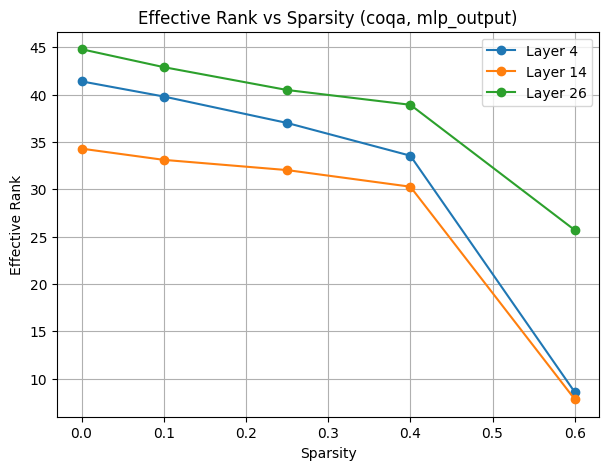

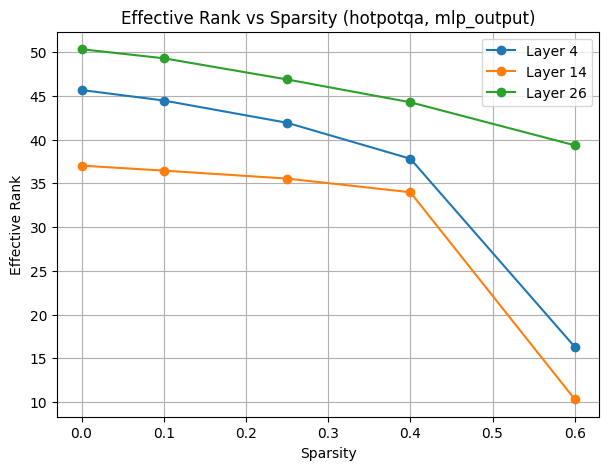

In [10]:
#Plot stable rank vs sparsity. This is optional but useful as a second compact metric.
df = pd.read_csv(csv_path)

for cal_ds in DATASETS:
    plt.figure(figsize=(7, 5))
    sub = df[df["calibration_dataset"] == cal_ds]

    for layer_idx in LAYERS_TO_ANALYZE:
        layer_df = sub[sub["layer"] == layer_idx].sort_values("sparsity")
        plt.plot(
            layer_df["sparsity"],
            layer_df["effective_rank"],
            marker="o",
            label=f"Layer {layer_idx}"
        )

    plt.title(f"Effective Rank vs Sparsity ({cal_ds}, {ACTIVATION_KIND})")
    plt.xlabel("Sparsity")
    plt.ylabel("Effective Rank")
    plt.grid(True)
    plt.legend()
    plt.show()

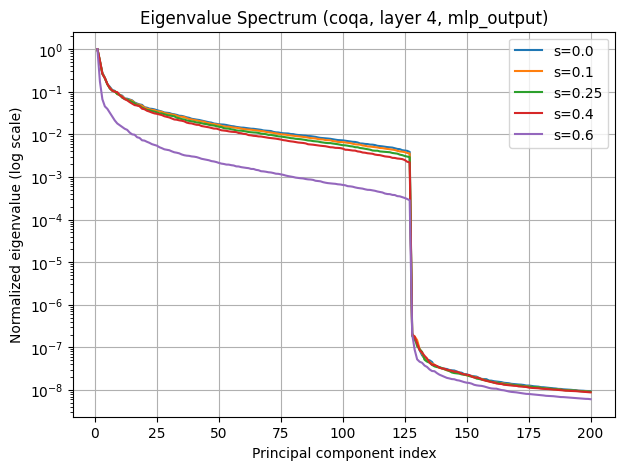

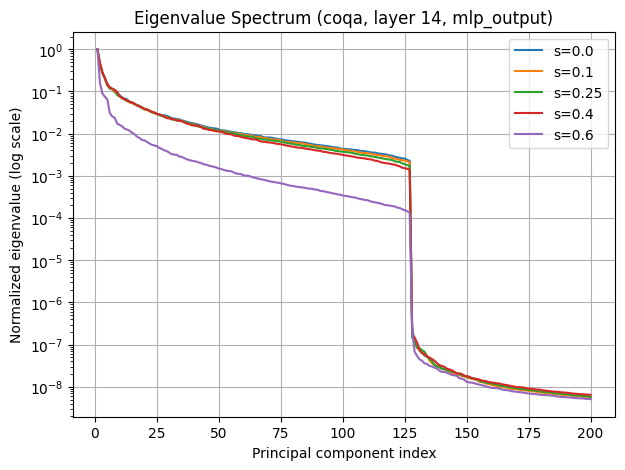

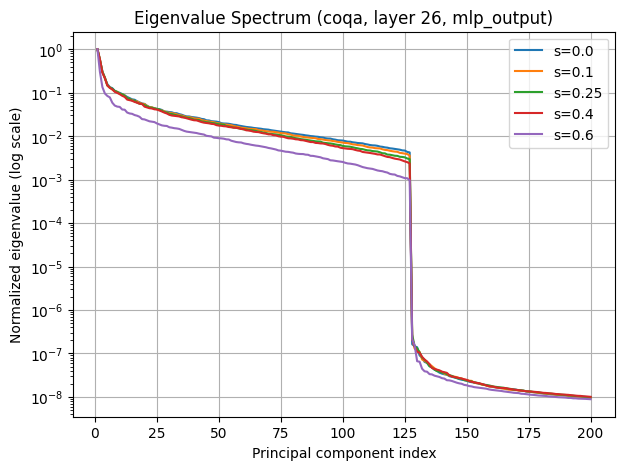

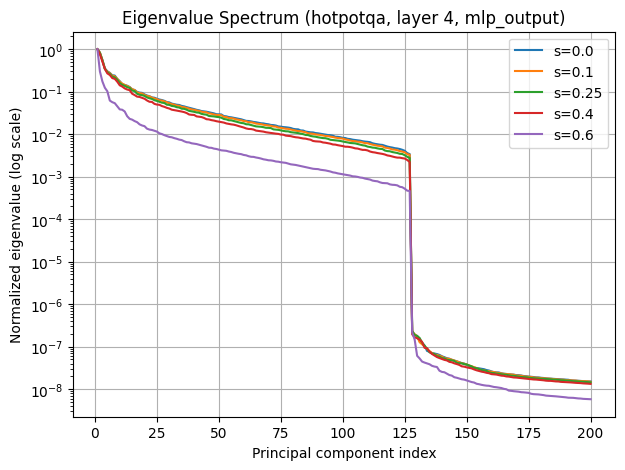

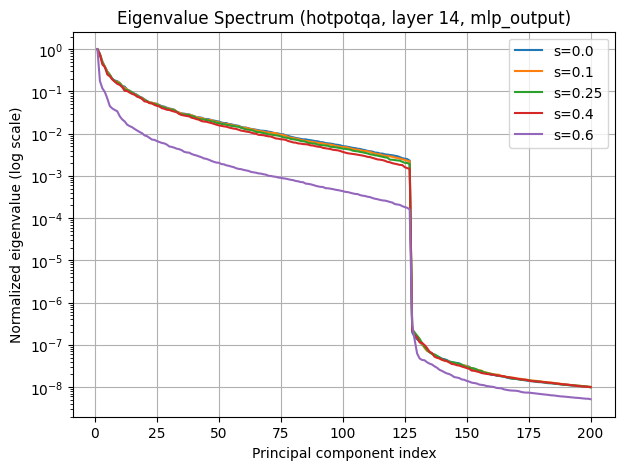

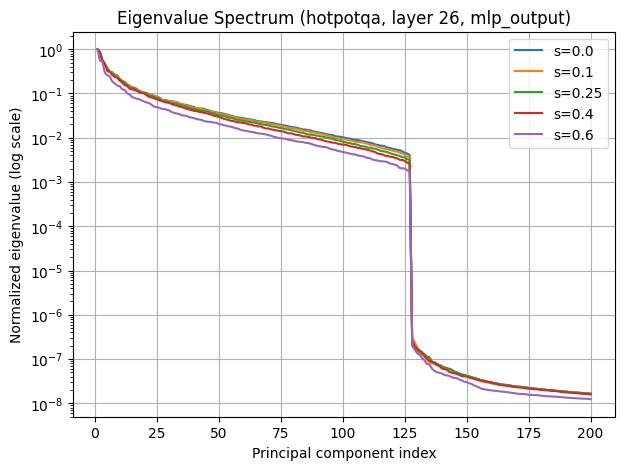

In [11]:
#Plot eigenvalue spectra for one layer. This shows whether the tail gets compressed at moderate sparsity.
def load_result_json(cal_ds: str, sparsity: float, layer_idx: int):
    name = f"{cal_ds}_s{sparsity:.2f}_layer{layer_idx}_{ACTIVATION_KIND}_spectrum.json"
    path = os.path.join(ANALYSIS_DIR, name)
    with open(path, "r") as f:
        return json.load(f)


def plot_spectrum_for_layer(cal_ds: str, layer_idx: int):
    plt.figure(figsize=(7, 5))

    for sparsity in SPARSITIES:
        result = load_result_json(cal_ds, sparsity, layer_idx)
        eigs = np.array(result["eigenvalues_topk"], dtype=np.float64)

        # normalize by first eigenvalue for easier comparison
        eigs = eigs / (eigs[0] + EPS)

        plt.plot(
            np.arange(1, len(eigs) + 1),
            eigs,
            marker=None,
            label=f"s={sparsity}"
        )

    plt.yscale("log")
    plt.title(f"Eigenvalue Spectrum ({cal_ds}, layer {layer_idx}, {ACTIVATION_KIND})")
    plt.xlabel("Principal component index")
    plt.ylabel("Normalized eigenvalue (log scale)")
    plt.grid(True)
    plt.legend()
    plt.show()


# Example plots
for ds in DATASETS:
    for layer_idx in LAYERS_TO_ANALYZE:
        plot_spectrum_for_layer(ds, layer_idx)

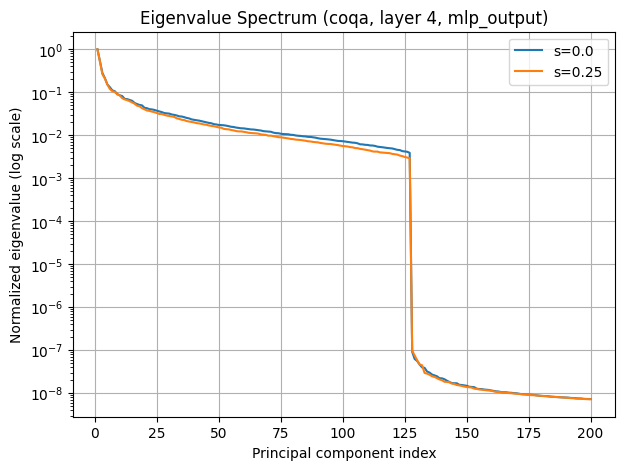

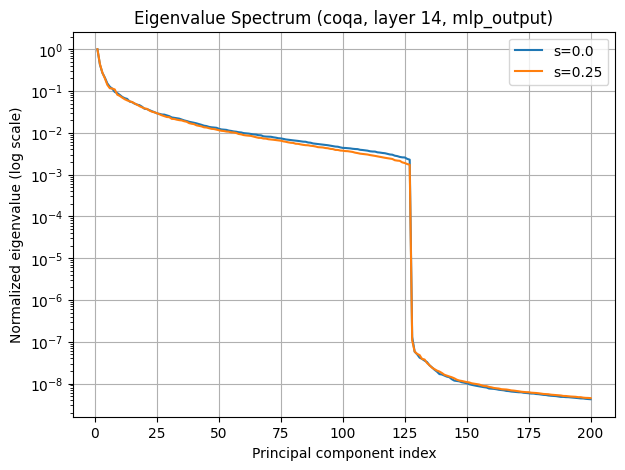

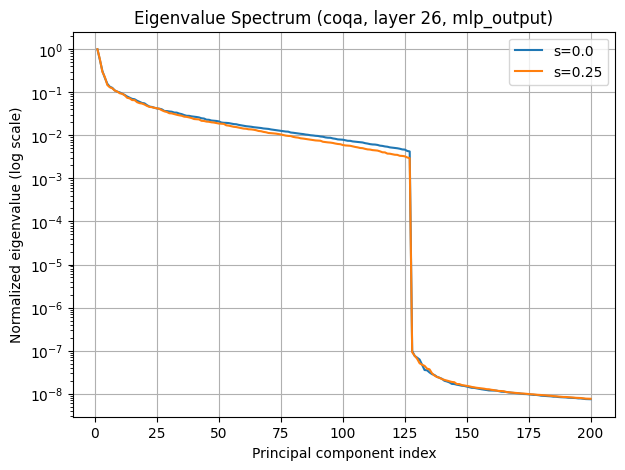

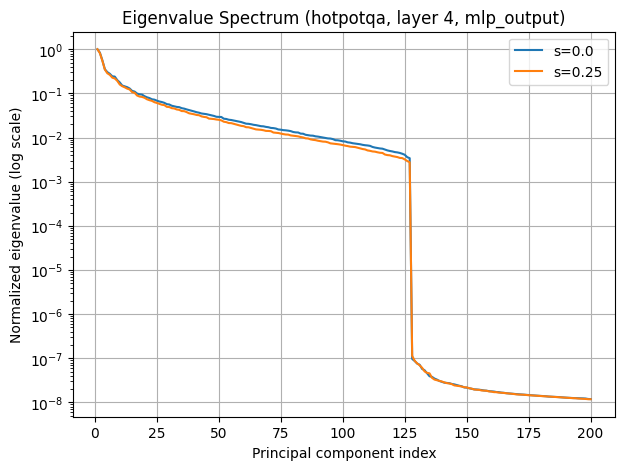

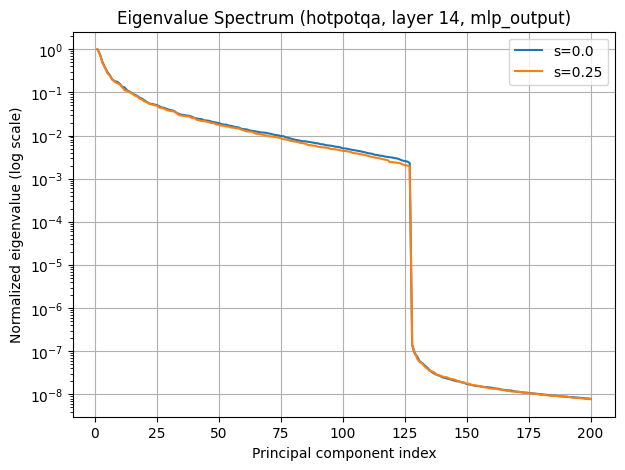

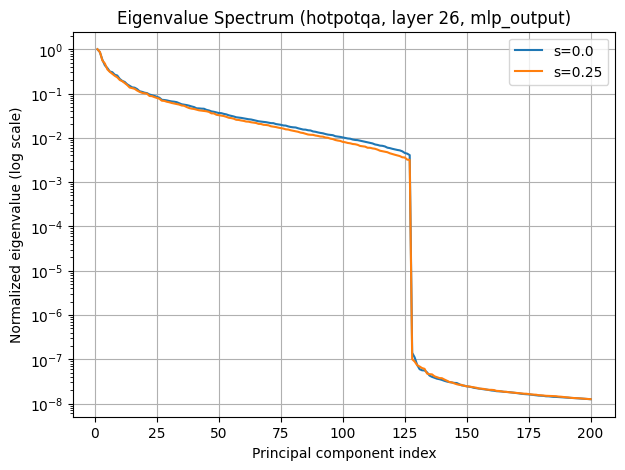

In [ ]:
#Plot eigenvalue spectra for one layer. This shows whether the tail gets compressed at moderate sparsity.
def load_result_json(cal_ds: str, sparsity: float, layer_idx: int):
    name = f"{cal_ds}_s{sparsity:.2f}_layer{layer_idx}_{ACTIVATION_KIND}_spectrum.json"
    path = os.path.join(ANALYSIS_DIR, name)
    with open(path, "r") as f:
        return json.load(f)


def plot_spectrum_for_layer(cal_ds: str, layer_idx: int):
    plt.figure(figsize=(7, 5))

    for sparsity in [0.0,0.25]:
        result = load_result_json(cal_ds, sparsity, layer_idx)
        eigs = np.array(result["eigenvalues_topk"], dtype=np.float64)

        # normalize by first eigenvalue for easier comparison
        eigs = eigs / (eigs[0] + EPS)

        plt.plot(
            np.arange(1, len(eigs) + 1),
            eigs,
            marker=None,
            label=f"s={sparsity}"
        )

    plt.yscale("log")
    plt.title(f"Eigenvalue Spectrum ({cal_ds}, layer {layer_idx}, {ACTIVATION_KIND})")
    plt.xlabel("Principal component index")
    plt.ylabel("Normalized eigenvalue (log scale)")
    plt.grid(True)
    plt.legend()
    plt.show()


# Example plots
for ds in DATASETS:
    for layer_idx in LAYERS_TO_ANALYZE:
        plot_spectrum_for_layer(ds, layer_idx)

In [12]:
#Build a compact interpretation table. Useful for the report.
pivot_eff = df.pivot_table(
    index=["calibration_dataset", "layer"],
    columns="sparsity",
    values="effective_rank"
)

pivot_stable = df.pivot_table(
    index=["calibration_dataset", "layer"],
    columns="sparsity",
    values="stable_rank"
)

print("Effective rank table:")
display(pivot_eff)

print("\nStable rank table:")
display(pivot_stable)

Effective rank table:


sparsity                        0.00       0.10       0.25       0.40  \
calibration_dataset layer                                               
coqa                4      41.402163  39.802185  37.010601  33.551899   
                    14     34.295778  33.111426  32.031892  30.276498   
                    26     44.796851  42.904223  40.489943  38.927714   
hotpotqa            4      45.673725  44.474391  41.930247  37.817248   
                    14     37.028598  36.457790  35.547156  33.982008   
                    26     50.340366  49.304507  46.884069  44.273854   

sparsity                        0.60  
calibration_dataset layer             
coqa                4       8.582886  
                    14      7.830302  
                    26     25.695404  
hotpotqa            4      16.302507  
                    14     10.312014  
                    26     39.354320


Stable rank table:


sparsity                       0.00      0.10      0.25      0.40      0.60
calibration_dataset layer                                                  
coqa                4      1.555277  1.537620  1.515932  1.526713  1.043172
                    14     1.427455  1.419778  1.427305  1.485626  1.047747
                    26     1.645977  1.636884  1.645605  1.636079  1.161251
hotpotqa            4      2.723163  2.699573  2.580682  2.367046  1.168077
                    14     2.417656  2.382663  2.342227  2.237221  1.069111
                    26     3.119208  3.088913  3.050105  2.942871  2.028813

In [ ]:
###############################

In [9]:
import torch
import numpy as np

def pca_reconstruction_error(H, k_list):
    """
    Compute PCA reconstruction error for different k.

    Returns:
        dict: {k : reconstruction_error}
    """

    H = H.float()

    # center
    Hc = H - H.mean(dim=0, keepdim=True)

    # covariance
    C = (Hc.T @ Hc) / (Hc.shape[0] - 1)

    # eigen decomposition
    eigvals, eigvecs = torch.linalg.eigh(C)

    # sort descending
    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    errors = {}

    for k in k_list:

        Vk = eigvecs[:, :k]

        # project
        H_proj = Hc @ Vk

        # reconstruct
        H_rec = H_proj @ Vk.T

        # error
        err = torch.norm(Hc - H_rec, p='fro') / torch.norm(Hc, p='fro')

        errors[k] = err.item()

    return errors

In [10]:
K_LIST = [5, 10, 20, 40, 60, 80, 100]

In [11]:
results = {}

for sparsity in [0.0, 0.10, 0.25, 0.40, 0.60]:

    path = hidden_state_file("coqa", sparsity, 14)  # layer 26 example

    print("Loading:", path)

    x = torch.load(path, map_location="cpu")
    H = to_sample_feature_matrix(x)

    errors = pca_reconstruction_error(H, K_LIST)

    results[sparsity] = errors

Loading: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca/Qwen-Qwen2-1p5B-Instruct_coqa_s0p00/hidden_states/layer_14_mlp_output.pt
Loading: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca/Qwen-Qwen2-1p5B-Instruct_coqa_s0p10/hidden_states/layer_14_mlp_output.pt
Loading: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca/Qwen-Qwen2-1p5B-Instruct_coqa_s0p25/hidden_states/layer_14_mlp_output.pt
Loading: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca/Qwen-Qwen2-1p5B-Instruct_coqa_s0p40/hidden_states/layer_14_mlp_output.pt
Loading: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca/Qwen-Qwen2-1p5B-Instruct_coqa_s0p60/hidden_states/layer_14_mlp_output.pt


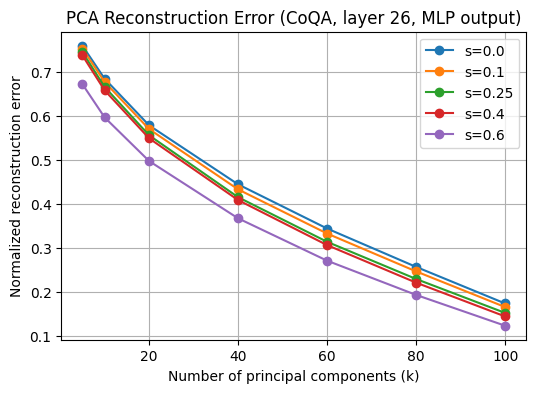

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

for sparsity, errors in results.items():

    ks = list(errors.keys())
    vals = list(errors.values())

    plt.plot(ks, vals, marker="o", label=f"s={sparsity}")

plt.xlabel("Number of principal components (k)")
plt.ylabel("Normalized reconstruction error")
plt.title("PCA Reconstruction Error (CoQA, layer 26, MLP output)")
plt.legend()
plt.grid(True)

plt.show()

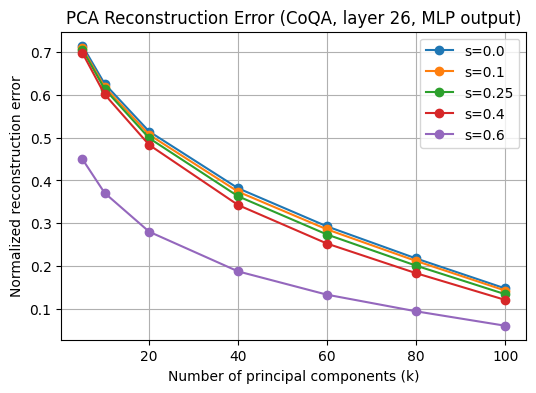

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

for sparsity, errors in results.items():

    ks = list(errors.keys())
    vals = list(errors.values())

    plt.plot(ks, vals, marker="o", label=f"s={sparsity}")

plt.xlabel("Number of principal components (k)")
plt.ylabel("Normalized reconstruction error")
plt.title("PCA Reconstruction Error (CoQA, layer 26, MLP output)")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
######################################################

In [4]:
# ==========================================
# Cross-dataset reconstruction experiment
# Probe: SQuADv2 HasAns hidden states
# Basis: CoQA hidden states at different sparsities
# ==========================================

PROBE_DATASET = "squad2"
CALIBRATION_DATASET = "coqa"

LAYER_IDX = 14
K_LIST = [5, 10, 20, 40, 60, 80, 100]

CROSS_ANALYSIS_DIR = os.path.join(
    ANALYSIS_DIR,
    f"cross_reconstruction_{CALIBRATION_DATASET}_to_{PROBE_DATASET}"
)
os.makedirs(CROSS_ANALYSIS_DIR, exist_ok=True)

print("Probe dataset:", PROBE_DATASET)
print("Calibration dataset:", CALIBRATION_DATASET)
print("Layer:", LAYER_IDX)
print("K values:", K_LIST)
print("Cross-analysis dir:", CROSS_ANALYSIS_DIR)

Probe dataset: squad2
Calibration dataset: coqa
Layer: 14
K values: [5, 10, 20, 40, 60, 80, 100]
Cross-analysis dir: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/cross_reconstruction_coqa_to_squad2


In [15]:
probe_path = hidden_state_file(PROBE_DATASET, 0.0, LAYER_IDX)

print("Probe path:", probe_path)
print("Exists:", os.path.exists(probe_path))

x_probe = torch.load(probe_path, map_location="cpu")
H_probe = to_sample_feature_matrix(x_probe)

print("H_probe shape:", tuple(H_probe.shape))
print("H_probe dtype:", H_probe.dtype)

Probe path: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/models_Qwen2-1.5B-Instruct_pca/Qwen-Qwen2-1p5B-Instruct_squad2_s0p00/hidden_states/layer_14_mlp_output.pt
Exists: True
H_probe shape: (128, 1536)
H_probe dtype: torch.float32


In [16]:
def compute_pca_basis(H: torch.Tensor):
    """
    Compute PCA basis from H in R^{N x d}.

    Returns:
        dict with:
          - mean: (d,)
          - eigvals: (d,)
          - eigvecs: (d, d), sorted descending
          - n_samples
          - hidden_dim
    """
    H = H.float()
    mu = H.mean(dim=0, keepdim=True)
    Hc = H - mu

    N, d = Hc.shape
    if N < 2:
        raise ValueError("Need at least 2 samples.")

    C = (Hc.T @ Hc) / (N - 1)

    eigvals, eigvecs = torch.linalg.eigh(C)

    idx = torch.argsort(eigvals, descending=True)
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    eigvals = torch.clamp(eigvals, min=0.0)

    return {
        "mean": mu.squeeze(0),
        "eigvals": eigvals,
        "eigvecs": eigvecs,
        "n_samples": int(N),
        "hidden_dim": int(d),
    }


def reconstruction_error_from_basis(H_probe: torch.Tensor, V: torch.Tensor, k_list):
    """
    Reconstruct centered probe hidden states using basis V.

    H_probe: (N, d)
    V: (d, d) PCA eigenvectors
    k_list: list of k values

    Returns:
        dict {k: normalized Frobenius reconstruction error}
    """
    H_probe = H_probe.float()
    Hc = H_probe - H_probe.mean(dim=0, keepdim=True)

    denom = torch.norm(Hc, p="fro") + EPS
    errors = {}

    for k in k_list:
        Vk = V[:, :k]
        H_rec = Hc @ Vk @ Vk.T
        err = torch.norm(Hc - H_rec, p="fro") / denom
        errors[k] = float(err.item())

    return errors

In [17]:
cross_results = []

for sparsity in SPARSITIES:
    cal_path = hidden_state_file(CALIBRATION_DATASET, sparsity, LAYER_IDX)

    if not os.path.exists(cal_path):
        print(f"[WARNING] Missing calibration file: {cal_path}")
        continue

    print(f"[RUN] basis={CALIBRATION_DATASET} | sparsity={sparsity} | layer={LAYER_IDX}")

    x_cal = torch.load(cal_path, map_location="cpu")
    H_cal = to_sample_feature_matrix(x_cal)

    pca = compute_pca_basis(H_cal)
    errors = reconstruction_error_from_basis(H_probe, pca["eigvecs"], K_LIST)

    for k, err in errors.items():
        cross_results.append({
            "probe_dataset": PROBE_DATASET,
            "basis_dataset": CALIBRATION_DATASET,
            "basis_sparsity": sparsity,
            "layer": LAYER_IDX,
            "activation_kind": ACTIVATION_KIND,
            "k": k,
            "reconstruction_error": err,
            "basis_n_samples": pca["n_samples"],
            "hidden_dim": pca["hidden_dim"],
        })

print(f"\nCompleted {len(cross_results)} measurements.")

[RUN] basis=coqa | sparsity=0.0 | layer=14
[RUN] basis=coqa | sparsity=0.1 | layer=14
[RUN] basis=coqa | sparsity=0.25 | layer=14
[RUN] basis=coqa | sparsity=0.4 | layer=14
[RUN] basis=coqa | sparsity=0.6 | layer=14

Completed 35 measurements.


In [18]:
probe_pca = compute_pca_basis(H_probe)
probe_self_errors = reconstruction_error_from_basis(H_probe, probe_pca["eigvecs"], K_LIST)

for k, err in probe_self_errors.items():
    cross_results.append({
        "probe_dataset": PROBE_DATASET,
        "basis_dataset": "self_probe_basis",
        "basis_sparsity": -1.0,
        "layer": LAYER_IDX,
        "activation_kind": ACTIVATION_KIND,
        "k": k,
        "reconstruction_error": err,
        "basis_n_samples": probe_pca["n_samples"],
        "hidden_dim": probe_pca["hidden_dim"],
    })

print("Added self-basis baseline.")

Added self-basis baseline.


In [14]:
cross_df = pd.DataFrame(cross_results)

cross_csv_path = os.path.join(
    CROSS_ANALYSIS_DIR,
    f"layer{LAYER_IDX}_{ACTIVATION_KIND}_cross_reconstruction.csv"
)

cross_json_path = os.path.join(
    CROSS_ANALYSIS_DIR,
    f"layer{LAYER_IDX}_{ACTIVATION_KIND}_cross_reconstruction.json"
)

cross_df.to_csv(cross_csv_path, index=False)
with open(cross_json_path, "w") as f:
    json.dump(cross_results, f, indent=2)

print("Saved CSV:", cross_csv_path)
print("Saved JSON:", cross_json_path)

display(cross_df.head())

Saved CSV: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/cross_reconstruction_coqa_to_squad2/layer26_mlp_output_cross_reconstruction.csv
Saved JSON: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/cross_reconstruction_coqa_to_squad2/layer26_mlp_output_cross_reconstruction.json


,probe_dataset,basis_dataset,basis_sparsity,layer,activation_kind,k,reconstruction_error,basis_n_samples,hidden_dim
0,squad2,coqa,0.0,26,mlp_output,5,0.931050,128,1536
1,squad2,coqa,0.0,26,mlp_output,10,0.878177,128,1536
2,squad2,coqa,0.0,26,mlp_output,20,0.827466,128,1536
3,squad2,coqa,0.0,26,mlp_output,40,0.774128,128,1536
4,squad2,coqa,0.0,26,mlp_output,60,0.740734,128,1536


In [19]:
cross_df = pd.DataFrame(cross_results)

cross_csv_path = os.path.join(
    CROSS_ANALYSIS_DIR,
    f"layer{LAYER_IDX}_{ACTIVATION_KIND}_cross_reconstruction.csv"
)

cross_json_path = os.path.join(
    CROSS_ANALYSIS_DIR,
    f"layer{LAYER_IDX}_{ACTIVATION_KIND}_cross_reconstruction.json"
)

cross_df.to_csv(cross_csv_path, index=False)
with open(cross_json_path, "w") as f:
    json.dump(cross_results, f, indent=2)

print("Saved CSV:", cross_csv_path)
print("Saved JSON:", cross_json_path)

display(cross_df.head())

Saved CSV: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/cross_reconstruction_coqa_to_squad2/layer14_mlp_output_cross_reconstruction.csv
Saved JSON: /content/drive/MyDrive/TUM/Pratikum/SliceGPTExperiments/analysis_Qwen2-1.5B-Instruct_pca_spike/cross_reconstruction_coqa_to_squad2/layer14_mlp_output_cross_reconstruction.json


,probe_dataset,basis_dataset,basis_sparsity,layer,activation_kind,k,reconstruction_error,basis_n_samples,hidden_dim
0,squad2,coqa,0.0,14,mlp_output,5,0.901923,128,1536
1,squad2,coqa,0.0,14,mlp_output,10,0.829678,128,1536
2,squad2,coqa,0.0,14,mlp_output,20,0.773406,128,1536
3,squad2,coqa,0.0,14,mlp_output,40,0.704992,128,1536
4,squad2,coqa,0.0,14,mlp_output,60,0.670761,128,1536


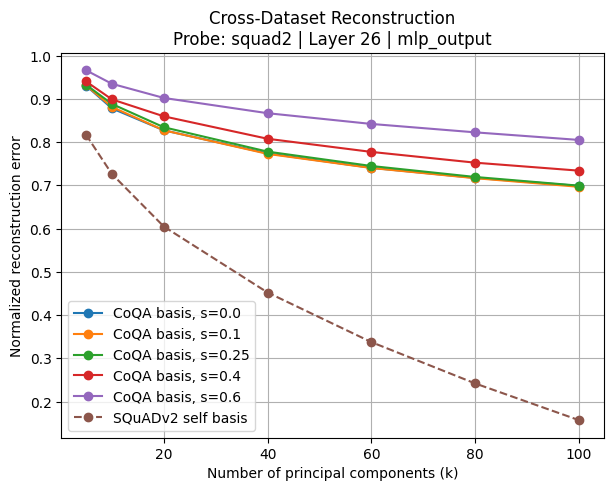

In [15]:
plt.figure(figsize=(7, 5))

sub = cross_df[cross_df["basis_dataset"] == CALIBRATION_DATASET]

for sparsity in sorted(sub["basis_sparsity"].unique()):
    cur = sub[sub["basis_sparsity"] == sparsity].sort_values("k")
    plt.plot(
        cur["k"],
        cur["reconstruction_error"],
        marker="o",
        label=f"CoQA basis, s={sparsity}"
    )

self_df = cross_df[cross_df["basis_dataset"] == "self_probe_basis"].sort_values("k")
if len(self_df) > 0:
    plt.plot(
        self_df["k"],
        self_df["reconstruction_error"],
        marker="o",
        linestyle="--",
        label="SQuADv2 self basis"
    )

plt.xlabel("Number of principal components (k)")
plt.ylabel("Normalized reconstruction error")
plt.title(f"Cross-Dataset Reconstruction\nProbe: {PROBE_DATASET} | Layer {LAYER_IDX} | {ACTIVATION_KIND}")
plt.grid(True)
plt.legend()
plt.show()

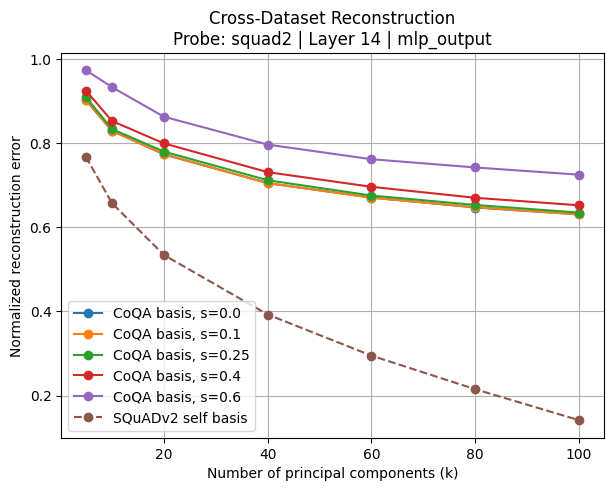

In [20]:
plt.figure(figsize=(7, 5))

sub = cross_df[cross_df["basis_dataset"] == CALIBRATION_DATASET]

for sparsity in sorted(sub["basis_sparsity"].unique()):
    cur = sub[sub["basis_sparsity"] == sparsity].sort_values("k")
    plt.plot(
        cur["k"],
        cur["reconstruction_error"],
        marker="o",
        label=f"CoQA basis, s={sparsity}"
    )

self_df = cross_df[cross_df["basis_dataset"] == "self_probe_basis"].sort_values("k")
if len(self_df) > 0:
    plt.plot(
        self_df["k"],
        self_df["reconstruction_error"],
        marker="o",
        linestyle="--",
        label="SQuADv2 self basis"
    )

plt.xlabel("Number of principal components (k)")
plt.ylabel("Normalized reconstruction error")
plt.title(f"Cross-Dataset Reconstruction\nProbe: {PROBE_DATASET} | Layer {LAYER_IDX} | {ACTIVATION_KIND}")
plt.grid(True)
plt.legend()
plt.show()

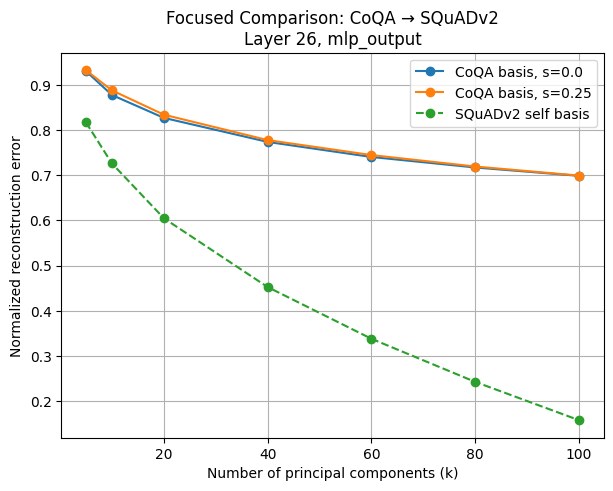

In [16]:
plt.figure(figsize=(7, 5))

focus_sparsities = [0.0, 0.25]

for sparsity in focus_sparsities:
    cur = cross_df[
        (cross_df["basis_dataset"] == CALIBRATION_DATASET) &
        (cross_df["basis_sparsity"] == sparsity)
    ].sort_values("k")

    if len(cur) == 0:
        continue

    plt.plot(
        cur["k"],
        cur["reconstruction_error"],
        marker="o",
        label=f"CoQA basis, s={sparsity}"
    )

self_df = cross_df[cross_df["basis_dataset"] == "self_probe_basis"].sort_values("k")
if len(self_df) > 0:
    plt.plot(
        self_df["k"],
        self_df["reconstruction_error"],
        marker="o",
        linestyle="--",
        label="SQuADv2 self basis"
    )

plt.xlabel("Number of principal components (k)")
plt.ylabel("Normalized reconstruction error")
plt.title(f"Focused Comparison: CoQA → SQuADv2\nLayer {LAYER_IDX}, {ACTIVATION_KIND}")
plt.grid(True)
plt.legend()
plt.show()

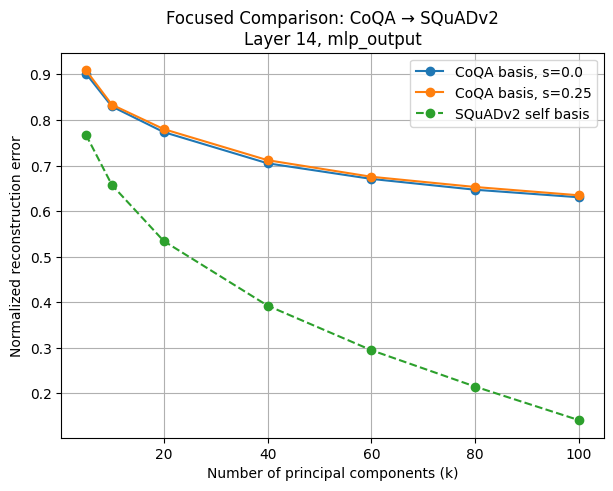

In [21]:
plt.figure(figsize=(7, 5))

focus_sparsities = [0.0, 0.25]

for sparsity in focus_sparsities:
    cur = cross_df[
        (cross_df["basis_dataset"] == CALIBRATION_DATASET) &
        (cross_df["basis_sparsity"] == sparsity)
    ].sort_values("k")

    if len(cur) == 0:
        continue

    plt.plot(
        cur["k"],
        cur["reconstruction_error"],
        marker="o",
        label=f"CoQA basis, s={sparsity}"
    )

self_df = cross_df[cross_df["basis_dataset"] == "self_probe_basis"].sort_values("k")
if len(self_df) > 0:
    plt.plot(
        self_df["k"],
        self_df["reconstruction_error"],
        marker="o",
        linestyle="--",
        label="SQuADv2 self basis"
    )

plt.xlabel("Number of principal components (k)")
plt.ylabel("Normalized reconstruction error")
plt.title(f"Focused Comparison: CoQA → SQuADv2\nLayer {LAYER_IDX}, {ACTIVATION_KIND}")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
pivot = cross_df.pivot_table(
    index="k",
    columns=["basis_dataset", "basis_sparsity"],
    values="reconstruction_error"
)

display(pivot)

basis_dataset       coqa                                          \
basis_sparsity      0.00      0.10      0.25      0.40      0.60   
k                                                                  
5               0.931050  0.931797  0.933044  0.940643  0.966379   
10              0.878177  0.881427  0.888398  0.898927  0.935000   
20              0.827466  0.827549  0.834550  0.859795  0.902296   
40              0.774128  0.772948  0.778148  0.807893  0.867016   
60              0.740734  0.740323  0.744928  0.777497  0.842170   
80              0.717440  0.716787  0.719559  0.752622  0.822733   
100             0.698914  0.696821  0.699475  0.734159  0.805176   

basis_dataset  self_probe_basis  
basis_sparsity            -1.00  
k                                
5                      0.817516  
10                     0.726465  
20                     0.605044  
40                     0.452424  
60                     0.337736  
80                     0.242160  
100                    0.157237

In [22]:
pivot = cross_df.pivot_table(
    index="k",
    columns=["basis_dataset", "basis_sparsity"],
    values="reconstruction_error"
)

display(pivot)

basis_dataset       coqa                                          \
basis_sparsity      0.00      0.10      0.25      0.40      0.60   
k                                                                  
5               0.901923  0.903715  0.909245  0.924971  0.973359   
10              0.829678  0.828964  0.833614  0.852739  0.933208   
20              0.773406  0.774130  0.779950  0.799534  0.862931   
40              0.704992  0.705058  0.711835  0.731109  0.796573   
60              0.670761  0.670216  0.675450  0.696184  0.761776   
80              0.647020  0.647791  0.653009  0.670087  0.742209   
100             0.630467  0.630604  0.634804  0.652231  0.725011   

basis_dataset  self_probe_basis  
basis_sparsity            -1.00  
k                                
5                      0.767666  
10                     0.657528  
20                     0.534356  
40                     0.392652  
60                     0.294899  
80                     0.214995  
100                    0.141339